# FUSION MULTIMODALE

L’objectif est de développer une approche multimodale combinant texte et images afin d’améliorer la 
classification multi-label, en s’appuyant sur les résultats obtenus dans les parties unimodales.

In [ ]:
import os, ast, json, pickle, math
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout,GRU
from tensorflow.keras.callbacks import EarlyStopping

from tensorflow.keras import layers, Model, Input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

from sklearn.metrics import f1_score
import nltk
from nltk.corpus import stopwords
import re
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, BatchNormalization, Activation,
                                      MaxPooling2D, Flatten, Dense, Dropout,GlobalAveragePooling2D,Rescaling)
from lime.lime_text import LimeTextExplainer
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.preprocessing import RobustScaler

from util_fusion import (labels_to_vector,preprocess_text,build_joint_fusion,
                         build_joint_dataset, optimize_thresholds, plot_fusion_curves,
                         plot_confusion_matrices, load_and_preprocess, build_dataset )


In [22]:
nltk.download("stopwords", quiet=True)

True

# Data loading and preparation

In [23]:
data_dir ="/kaggle/input/datasets/graceannexes/multimodality-classification/COMP5329S1A2Dataset/data"
df_dir ="/kaggle/input/datasets/graceannexes/final-multimodality-train-val-test/"
df_train = pd.read_csv(df_dir+"train_split.csv")
df_val = pd.read_csv(df_dir+"val_split.csv")
df_test = pd.read_csv(df_dir+"test_split.csv")

tokenizer_path = df_dir+"tokenizer.pkl"
text_model_path = df_dir+"model_texte_final.h5"
image_model_path = df_dir+"model_image_final.keras"

print("TRAIN DF")
display(df_train.head(3))

print("VAL DF")
display(df_val.head(3))

print("TEST DF")
display(df_test.head(3))

TRAIN DF


,ImageID,Labels,Caption,caption_length,nb_labels
0,3.jpg,"[8, 3, 13]",a black and silver clock tower at an intersect...,12,3
1,5.jpg,[1],A young man riding a skateboard into the air.,9,1
2,6.jpg,[5],A big airplane flying in the big blue sky,9,1


VAL DF


,ImageID,Labels,Caption,caption_length,nb_labels
0,0.jpg,[1],Woman in swim suit holding parasol on sunny day.,9,1
1,2.jpg,[1],They are brave for riding in the jungle on tho...,11,1
2,4.jpg,"[8, 3, 7]",A train coming to a stop on the tracks out side.,11,3


TEST DF


,ImageID,Labels,Caption,caption_length,nb_labels
0,1.jpg,"[1, 19]",A couple of men riding horses on top of a gree...,12,2
1,9.jpg,"[1, 18, 15]",A skate park next to a body of water and green...,12,3
2,12.jpg,"[1, 15]",A piece of cake and coffee are on an outdoor t...,11,2


# Preprocessing
setup des variables utilisées dans les précédents notebooks

In [24]:
np.random.seed(42)
tf.random.set_seed(42)
IMG_SIZE     = 224
BATCH_SIZE   = 32
MAX_LEN      = 20
MAX_WORDS    = 5000
EMBEDDING_DIM = 50
NUM_CLASSES  = 18
ALL_LABELS   = [1,2,3,4,5,6,7,8,9,10,11,13,14,15,16,17,18,19]

### Encodage des labels

Nous convertissons chaque liste de labels en vecteur binaire de
dimension 18 (un bit par classe). C'est la représentation attendue par
le modèle pour la classification multi-label.


In [ ]:
df_train["Labels"] = df_train["Labels"].apply(ast.literal_eval)
df_val["Labels"]   = df_val["Labels"].apply(ast.literal_eval)
df_test["Labels"]  = df_test["Labels"].apply(ast.literal_eval)

print(df_train["Labels"].iloc[0])
print(type(df_train["Labels"].iloc[0]))

Y_train = np.stack([labels_to_vector(l) for l in df_train["Labels"]])
Y_val   = np.stack([labels_to_vector(l) for l in df_val["Labels"]])
Y_test  = np.stack([labels_to_vector(l) for l in df_test["Labels"]])

print("Y_train sum par classe :", Y_train.sum(axis=0))

[8, 3, 13]
<class 'list'>
Y_train sum par classe : [18466.   943.  3537.  1031.   916.  1131.   990.  1790.   844.  1192.
   490.   491.   204.  1567.   890.  1159.  1236.   826.]


### Text cleaning and tokeniszation


Pour chaque caption nous appliquons le traiement suivant:
* normalisation de la casse, afin d'éviter que "Person" et "person"
   soient traités comme deux tokens différents.
* Suppression des caractères non alphabétiques (ponctuation et chiffres)
* Suppression des stopwords NLTK tels que "the", "a", "is"
   qui n'apportent pas d'information.
* Filtre longueur > 2 pour éliminer les abréviations et résidus de tokenisation


In [28]:
stop_words = set(stopwords.words("english"))


for df in [df_train, df_val, df_test]:
    df["Caption_clean"] = df["Caption"].apply(preprocess_text)

with open(tokenizer_path, "rb") as f:
    tokenizer = pickle.load(f)

X_text_train = pad_sequences(tokenizer.texts_to_sequences(df_train["Caption_clean"]), maxlen=MAX_LEN, padding="post")
X_text_val   = pad_sequences(tokenizer.texts_to_sequences(df_val["Caption_clean"]),   maxlen=MAX_LEN, padding="post")
X_text_test  = pad_sequences(tokenizer.texts_to_sequences(df_test["Caption_clean"]),  maxlen=MAX_LEN, padding="post")

print(f"X_text_train : {X_text_train.shape}")

X_text_train : (24284, 20)


### chargement des modèles unimodaux

**Modèle de classification des images :** Nous reconstruisons l'architecture du modèle et chargeons les poids deja entrainés.

In [29]:
input_shape = (IMG_SIZE, IMG_SIZE, 3)

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=input_shape
)
base_model.trainable = False

inputs  = Input(shape=input_shape)
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = BatchNormalization()(x)
x       = Dense(256, activation="relu")(x)
x       = Dropout(0.4)(x)
x       = Dense(128, activation="relu")(x)
x       = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="sigmoid")(x)

model_image = tf.keras.Model(inputs, outputs, name="efficientnet_b0")

model_image.load_weights(image_model_path)
model_image.summary()

Model: "efficientnet_b0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,417,845 (16.85 MB)

 Trainable params: 365,714 (1.40 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

On crée un sous-modèle de model_image en le coupant avant la tête
de classification.

Le nouveau modèle image_encoder prend une image (224×224×3) en entrée
et produit un vecteur de 128 dimensions qui est la représentation apprise
par EfficientNetB0 + les couches denses pour la tâche multi-label.

On gèle tous les poids car ils ne seront
pas modifiés pendant l'entraînement de l'Early Fusion.

**Modèle de classification des textes :** Nous reconstruisons l'architecture du modèle et chargeons les poids deja entrainés.

In [30]:
image_encoder = Model(
    inputs=model_image.input,
    outputs=model_image.layers[-3].output,  
    name="image_encoder"
)
image_encoder.trainable = False

print("Image encoder output shape:", image_encoder.output_shape)  

Image encoder output shape: (None, 128)


In [31]:
import kagglehub
path = kagglehub.dataset_download("watts2/glove6b50dtxt")
print(path)

/kaggle/input/datasets/watts2/glove6b50dtxt


In [32]:
glove_path = path+"/glove.6B.50d.txt"

embeddings_index = {}
with open(glove_path, encoding="utf-8") as f:
    for line in f:
        vals = line.split()
        embeddings_index[vals[0]] = np.asarray(vals[1:], dtype="float32")

embedding_matrix = np.zeros((MAX_WORDS, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < MAX_WORDS:
        vec = embeddings_index.get(word)
        if vec is not None:
            embedding_matrix[i] = vec

print(f"embedding_matrix shape : {embedding_matrix.shape}") 

embedding_matrix shape : (5000, 50)


In [33]:
input_text_in = Input(shape=(MAX_LEN,), dtype="int32")
x = Embedding(input_dim=MAX_WORDS, output_dim=EMBEDDING_DIM, trainable=False)(input_text_in)
x = GRU(128)(x)
x = Dropout(0.5)(x)
output = Dense(NUM_CLASSES, activation="sigmoid")(x)

model_text = tf.keras.Model(input_text_in, output, name="gru_glove")

model_text.layers[1].set_weights([embedding_matrix])

model_text.load_weights(text_model_path)
print("Poids modèle texte chargés.")

text_encoder = Model(
    inputs=model_text.input,
    outputs=model_text.layers[2].output, 
    name="text_encoder"
)
text_encoder.trainable = False
print("Text encoder output shape:", text_encoder.output_shape) 

Poids modèle texte chargés.
Text encoder output shape: (None, 128)


## Embedding extraction

Le processus repose sur deux fonctions principales. D'abord, **load_image_np** assure le chargement et le prétraitement de chaque image sous forme d'array NumPy. Ensuite, **extract_image_embeddings** traite l'intégralité du dataset en organisant les données par lots pour effectuer une passe forward via l'encodeur et produire les résultats finaux.

In [ ]:
def load_image_np(img_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    return tf.cast(img, tf.float32).numpy()

def extract_image_embeddings(df, encoder, batch_size=64):
    img_paths  = [os.path.join(data_dir, fname) for fname in df["ImageID"]]
    embeddings = []
    for i in range(0, len(img_paths), batch_size):
        batch = np.stack([load_image_np(p) for p in img_paths[i:i+batch_size]])
        embeddings.append(encoder.predict(batch, verbose=0))
        if i % 3000 == 0:
            print(f"  {i}/{len(img_paths)}")
    return np.concatenate(embeddings, axis=0)


### Extraction des embeddings unimodaux

On extrait une seule fois
les représentations apprises par chaque modèle unimodal, avant de les
combiner.


In [35]:

print("Extraction embeddings image...")
E_img_train = extract_image_embeddings(df_train, image_encoder)
E_img_val   = extract_image_embeddings(df_val,   image_encoder)
E_img_test  = extract_image_embeddings(df_test,  image_encoder)

print("Extraction embeddings texte...")
E_txt_train = text_encoder.predict(X_text_train, batch_size=256, verbose=1)
E_txt_val   = text_encoder.predict(X_text_val,   batch_size=256, verbose=1)
E_txt_test  = text_encoder.predict(X_text_test,  batch_size=256, verbose=1)

print(f"\nE_img_train : {E_img_train.shape}")
print(f"E_txt_train : {E_txt_train.shape}")

Extraction embeddings image...


I0000 00:00:1775471062.150778      99 service.cc:152] XLA service 0x2a2567c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775471062.150819      99 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775471062.150823      99 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775471063.114427      99 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-04-06 10:24:29.585254: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:24:29.728148: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:24:30.074925: E external/local_xla/xl

  0/24284
  24000/24284


2026-04-06 10:30:48.030959: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:30:48.173449: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:30:48.514479: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:30:48.655780: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:30:49.423315: E external/local_xla/xla/stream_

  0/2693


2026-04-06 10:31:36.837783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:31:36.973332: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:31:37.288110: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:31:37.428570: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:31:38.206349: E external/local_xla/xla/stream_

  0/3023


2026-04-06 10:32:30.659530: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:32:30.799342: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:32:31.119099: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:32:31.260860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 10:32:32.034672: E external/local_xla/xla/stream_

Extraction embeddings texte...
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

E_img_train : (24284, 128)
E_txt_train : (24284, 128)


In [36]:
print("E_img_val — min/max/mean :")
print(f"  min  : {E_img_val.min():.6f}")
print(f"  max  : {E_img_val.max():.6f}")
print(f"  mean : {E_img_val.mean():.6f}")

print("\nE_txt_val — min/max/mean :")
print(f"  min  : {E_txt_val.min():.6f}")
print(f"  max  : {E_txt_val.max():.6f}")
print(f"  mean : {E_txt_val.mean():.6f}")

E_img_val — min/max/mean :
  min  : 0.000000
  max  : 13.055913
  mean : 0.620608

E_txt_val — min/max/mean :
  min  : -0.998795
  max  : 0.999286
  mean : -0.035498


Les embeddings image et texte ont des échelles très différentes avant fusion :

- Image : `[0, 13]`
- Texte : `[-1, 1]`

Sans normalisation, la tête de fusion est dominée par la modalité image dont les valeurs sont ~10x plus grandes.

Nous utiliserons `RobustScaler` pour la normalisation du fait de son insensibilité aux outliers et on garde un intervalle [-5, 5]



In [ ]:
scaler_img = RobustScaler()
E_img_train_scaled = scaler_img.fit_transform(E_img_train)
E_img_val_scaled   = scaler_img.transform(E_img_val)
E_img_test_scaled  = scaler_img.transform(E_img_test)

scaler_txt = RobustScaler()
E_txt_train_scaled = scaler_txt.fit_transform(E_txt_train)
E_txt_val_scaled   = scaler_txt.transform(E_txt_val)
E_txt_test_scaled  = scaler_txt.transform(E_txt_test)

E_img_train_scaled = np.clip(E_img_train_scaled, -5, 5)
E_img_val_scaled   = np.clip(E_img_val_scaled,   -5, 5)
E_img_test_scaled  = np.clip(E_img_test_scaled,  -5, 5)

E_txt_train_scaled = np.clip(E_txt_train_scaled, -5, 5)
E_txt_val_scaled   = np.clip(E_txt_val_scaled,   -5, 5)
E_txt_test_scaled  = np.clip(E_txt_test_scaled,  -5, 5)

print(f"E_img_train_scaled — min/max : {E_img_train_scaled.min():.3f} / {E_img_train_scaled.max():.3f}")
print(f"E_txt_train_scaled — min/max : {E_txt_train_scaled.min():.3f} / {E_txt_train_scaled.max():.3f}")

E_img_train_scaled — min/max : -0.986 / 5.000
E_txt_train_scaled — min/max : -5.000 / 5.000


# Early fusion

L'Early Fusion prend en entrée les embeddings pré-extraits des deux
encodeurs gelés et entraîne uniquement une tête de classification commune.


In [38]:
def build_early_fusion(embed_dim=128, num_classes=18):
    input_img  = Input(shape=(embed_dim,), name="img_embedding")
    input_text = Input(shape=(embed_dim,), name="text_embedding")

    fused = layers.Concatenate(name="fusion")([input_img, input_text])

    x = layers.Dense(128, activation="relu")(fused)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    output = layers.Dense(num_classes, activation="sigmoid")(x)

    return Model(inputs=[input_img, input_text], outputs=output, name="early_fusion")

model_early = build_early_fusion()
model_early.summary()


Model: "early_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ img_embedding       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ text_embedding      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 256)       │          0 │ img_embedding[0]… │
│ (Concatenate)       │                   │            │ text_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 128)       │     32,896 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_8[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 18)        │      2,322 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 35,730 (139.57 KB)

 Trainable params: 35,474 (138.57 KB)

 Non-trainable params: 256 (1.00 KB)

In [39]:
model_early.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[keras.metrics.AUC(curve="PR", name="auc_pr")]
)



Par cohérence avec les approches unimodales, on applique une
pondération inversement proportionnelle à la fréquence de chaque classe.

`class_weight = N_total / (N_classes × N_positifs_par_classe)`

Les poids sont ensuite normalisés par leur moyenne pour éviter
de modifier l'ordre de grandeur de la loss globale.

In [40]:
label_matrix  = Y_train
class_counts  = label_matrix.sum(axis=0)
class_weights = len(df_train) / (NUM_CLASSES * class_counts)
class_weights = class_weights / class_weights.mean()
class_weights_dict = dict(enumerate(class_weights))

print("Class weights :")
for i, (label, weight) in enumerate(zip(ALL_LABELS, class_weights)):
    print(f"  Label {label:2d} : {weight:.3f}")

Class weights :
  Label  1 : 0.045
  Label  2 : 0.885
  Label  3 : 0.236
  Label  4 : 0.810
  Label  5 : 0.911
  Label  6 : 0.738
  Label  7 : 0.843
  Label  8 : 0.466
  Label  9 : 0.989
  Label 10 : 0.700
  Label 11 : 1.704
  Label 13 : 1.700
  Label 14 : 4.093
  Label 15 : 0.533
  Label 16 : 0.938
  Label 17 : 0.720
  Label 18 : 0.675
  Label 19 : 1.011


In [41]:
es =  EarlyStopping(monitor="val_loss", patience=10,
                                   restore_best_weights=True, mode="min")



history_early = model_early.fit(
    x=[E_img_train_scaled, E_txt_train_scaled],
    y=Y_train,
    validation_data=([E_img_val_scaled, E_txt_val_scaled], Y_val),
    epochs=80,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,
    callbacks=es
)


Epoch 1/80
759/759 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - auc_pr: 0.3099 - loss: 0.0745 - val_auc_pr: 0.8419 - val_loss: 0.1149
Epoch 2/80
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc_pr: 0.8582 - loss: 0.0124 - val_auc_pr: 0.8706 - val_loss: 0.0989
Epoch 3/80
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc_pr: 0.8854 - loss: 0.0102 - val_auc_pr: 0.8728 - val_loss: 0.0996
Epoch 4/80
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc_pr: 0.8947 - loss: 0.0094 - val_auc_pr: 0.8742 - val_loss: 0.0992
Epoch 5/80
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc_pr: 0.8997 - loss: 0.0087 - val_auc_pr: 0.8795 - val_loss: 0.0967
Epoch 6/80
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc_pr: 0.9028 - loss: 0.0085 - val_auc_pr: 0.8776 - val_loss: 0.0992
Epoch 7/80
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc_pr: 0.9051 - loss: 0.0082 - val_auc_pr: 0.8759 - val_loss: 0.1007
Epoch 8/80
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - auc_pr: 0.9051 - loss: 0.0081 - val_auc_pr: 0.8758 - val_loss: 0.1004
Epoch 9/

In [42]:
print("Loss train :", history_early.history['loss'][:5])
print("Loss val   :", history_early.history['val_loss'][:5])

Y_proba_check = model_early.predict([E_img_val_scaled, E_txt_val_scaled])
print(f"min  : {Y_proba_check.min():.8f}")
print(f"max  : {Y_proba_check.max():.8f}")
print(f"mean : {Y_proba_check.mean():.8f}")


Loss train : [0.04036824032664299, 0.011528782546520233, 0.009845413267612457, 0.009162746369838715, 0.008680067025125027]
Loss val   : [0.11485887318849564, 0.09890392422676086, 0.09964337199926376, 0.09920511394739151, 0.09673672169446945]
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
min  : 0.00000000
max  : 0.99999738
mean : 0.07830226


# Join Fusion

Contrairement à l'Early Fusion qui combine des représentations figées,
le Joint Fusion intègre les deux modalités dans une architecture unifiée
entraînée conjointement. Les encodeurs s'adaptent mutuellement à la tâche.


In [45]:
print("Y_train sum :", Y_train.sum()) 

ds_train_joint = build_joint_dataset(df_train, X_text_train, Y_train, augment=True,  shuffle=True)
ds_val_joint   = build_joint_dataset(df_val,   X_text_val,   Y_val,   augment=False, shuffle=False)
ds_test_joint  = build_joint_dataset(df_test,  X_text_test,  Y_test,  augment=False, shuffle=False)



Y_train sum : 37703.0



### Entraînement Joint Fusion en deux phases 

**Phase 1 : Transfer Learning ( EfficientNetB0 gelé)**
EfficientNetB0 est gelé,
seule la tête de fusion est entraînée. Cela évite que les gradients
aléatoires de la tête ne dégradent les représentations pré-entraînées
sur ImageNet avant convergence.

**Phase 2 : Fine-tuning partiel (30 dernières couches dégelées)**
Contrairement à la classification image où EfficientNetB0 restait entièrement gelé,
on dégèle ici les 30 dernières couches.
L'objectif est d'adapter les features de haut niveau au contexte
multimodal.


**PHASE 1**

In [46]:
model_joint, base_joint = build_joint_fusion(model_image, embedding_matrix)
model_joint.compile(
    optimizer=Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[AUC(curve="PR", name="auc_pr")]
)
model_joint.summary()

Model: "joint_fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ text (InputLayer)   │ (None, 20)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 20, 50)    │    250,000 │ text[0][0]        │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 20, 50)    │          0 │ embedding_2[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 1280)      │  4,049,571 │ image[0][0]       │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_joint (GRU)     │ (None, 128)       │     69,120 │ spatial_dropout1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ img_proj (Dense)    │ (None, 128)       │    163,968 │ efficientnetb0[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ txt_proj (Dense)    │ (None, 128)       │     16,512 │ gru_joint[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ img_proj[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ txt_proj[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion              │ (None, 256)       │          0 │ dropout_7[0][0],  │
│ (Concatenate)       │                   │            │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 128)       │     32,896 │ fusion[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_10[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 18)        │      2,322 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,585,925 (17.49 MB)

 Trainable params: 535,586 (2.04 MB)

 Non-trainable params: 4,050,339 (15.45 MB)

In [49]:
checkpoint = keras.callbacks.ModelCheckpoint("joint_phase1_best.keras",
                                     monitor="val_loss", save_best_only=True, mode="min")


print("Joint Fusion — Phase 1")
history_joint_p1 = model_joint.fit(
    ds_train_joint, validation_data = ds_val_joint,
    epochs=30, callbacks= [es,checkpoint]
)

Joint Fusion — Phase 1
Epoch 1/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 64s 84ms/step - auc_pr: 0.9092 - loss: 0.0770 - val_auc_pr: 0.8943 - val_loss: 0.0851
Epoch 2/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 64s 85ms/step - auc_pr: 0.9134 - loss: 0.0743 - val_auc_pr: 0.8987 - val_loss: 0.0820
Epoch 3/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 63s 83ms/step - auc_pr: 0.9163 - loss: 0.0738 - val_auc_pr: 0.8999 - val_loss: 0.0822
Epoch 4/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 63s 83ms/step - auc_pr: 0.9194 - loss: 0.0718 - val_auc_pr: 0.8984 - val_loss: 0.0828
Epoch 5/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 66s 88ms/step - auc_pr: 0.9221 - loss: 0.0704 - val_auc_pr: 0.8971 - val_loss: 0.0847
Epoch 6/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 63s 83ms/step - auc_pr: 0.9255 - loss: 0.0687 - val_auc_pr: 0.8972 - val_loss: 0.0853
Epoch 7/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 63s 83ms/step - auc_pr: 0.9296 - loss: 0.0659 - val_auc_pr: 0.8971 - val_loss: 0.0849
Epoch 8/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 63s 83ms/step - auc_pr: 0.9300 - loss: 0.0656 - val_auc

#### Phase 2

In [50]:
base_joint.trainable = True
for layer in base_joint.layers[:-30]:
    layer.trainable = False

model_joint.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[AUC(curve="PR", name="auc_pr")]
)


In [51]:
checkpoint = keras.callbacks.ModelCheckpoint("joint_phase2.keras",
                                     monitor="val_loss", save_best_only=True, mode="min")

print("Joint Fusion — Phase 2")
history_joint_p2 = model_joint.fit(
    ds_train_joint, validation_data=ds_val_joint,
    epochs=30, callbacks=[es,checkpoint]
)

Joint Fusion — Phase 2
Epoch 1/30


E0000 00:00:1775472997.146376      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/joint_fusion_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


759/759 ━━━━━━━━━━━━━━━━━━━━ 91s 100ms/step - auc_pr: 0.9089 - loss: 0.0772 - val_auc_pr: 0.9055 - val_loss: 0.0794
Epoch 2/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 73s 96ms/step - auc_pr: 0.9243 - loss: 0.0689 - val_auc_pr: 0.9055 - val_loss: 0.0795
Epoch 3/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 73s 97ms/step - auc_pr: 0.9292 - loss: 0.0672 - val_auc_pr: 0.9049 - val_loss: 0.0796
Epoch 4/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 73s 97ms/step - auc_pr: 0.9357 - loss: 0.0631 - val_auc_pr: 0.9057 - val_loss: 0.0799
Epoch 5/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 73s 96ms/step - auc_pr: 0.9401 - loss: 0.0605 - val_auc_pr: 0.9035 - val_loss: 0.0812
Epoch 6/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 76s 101ms/step - auc_pr: 0.9444 - loss: 0.0579 - val_auc_pr: 0.9034 - val_loss: 0.0818
Epoch 7/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 74s 97ms/step - auc_pr: 0.9484 - loss: 0.0559 - val_auc_pr: 0.9023 - val_loss: 0.0831
Epoch 8/30
759/759 ━━━━━━━━━━━━━━━━━━━━ 74s 97ms/step - auc_pr: 0.9522 - loss: 0.0537 - val_auc_pr: 0.9005 - val_loss: 0.0849
E

# Evaluation

In [54]:
label_names = [f"Label {l}" for l in ALL_LABELS]

Y_proba_early_val  = model_early.predict([E_img_val,  E_txt_val])

print("EARLY FUSION")
thr_early  = optimize_thresholds(Y_val, Y_proba_early_val, label_names)
Y_pred_early = (Y_proba_early_val >= thr_early).astype(int)

print("JOINT FUSION")
Y_proba_joint_val  = model_joint.predict(ds_val_joint)

thr_joint  = optimize_thresholds(Y_val, Y_proba_joint_val, label_names)
Y_pred_joint = (Y_proba_joint_val >= thr_joint).astype(int)



85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
EARLY FUSION
=== Optimisation des seuils par classe ===

Label 1                   → seuil=0.55  F1=0.905
Label 2                   → seuil=0.10  F1=0.235
Label 3                   → seuil=0.10  F1=0.317
Label 4                   → seuil=0.10  F1=0.610
Label 5                   → seuil=0.10  F1=0.867
Label 6                   → seuil=0.10  F1=0.649
Label 7                   → seuil=0.10  F1=0.848
Label 8                   → seuil=0.10  F1=0.388
Label 9                   → seuil=0.10  F1=0.504
Label 10                  → seuil=0.10  F1=0.428
Label 11                  → seuil=0.10  F1=0.500
Label 13                  → seuil=0.10  F1=0.674
Label 14                  → seuil=0.10  F1=0.545
Label 15                  → seuil=0.10  F1=0.260
Label 16                  → seuil=0.15  F1=0.667
Label 17                  → seuil=0.10  F1=0.781
Label 18                  → seuil=0.10  F1=0.478
Label 19                  → seuil=0.10  F1=0.178
JOINT FUSION
85/85 ━━━

**Commentaire :**

* **Early Fusion** :
Les seuils optimaux se situent presque tous au minimum de 0.10, signalant que le modèle manque de confiance et produit des probabilités très faibles. Si les scores F1 sont satisfaisants sur les classes fréquentes (ex. Label 1 : 0.933), ils restent faibles sur les classes rares (ex. Label 2 : 0.235). Ce manque de performance s'explique par l'utilisation d'encodeurs gelés qui ne peuvent pas s'adapter conjointement aux spécificités de la tâche.

* **Joint Fusion** :
Ici, les seuils sont mieux calibrés, s'étalant entre 0.20 et 0.60. Les scores F1 progressent nettement sur toutes les catégories : les classes fréquentes dépassent les 0.94, tandis que les classes rares et difficiles connaissent une amélioration majeure (le Label 2 grimpe à 0.591 et le Label 9 à 0.793).


La méthode Joint Fusion surpasse systématiquement l'Early Fusion. En permettant aux représentations visuelles et textuelles de se co-adapter durant l'entraînement, cette approche offre une précision bien plus fine que la simple fusion de caractéristiques figées.

In [66]:
def compute_all_metrics(Y_true, Y_pred, name=""):
    print(f"\n{'='*50}\n{name}")
    for avg in ["macro", "micro", "weighted", "samples"]:
        score = f1_score(Y_true, Y_pred, average=avg, zero_division=0)
        print(f"  F1 {avg:<10}: {score:.4f}")



In [ ]:
compute_all_metrics(Y_val, Y_pred_early, "Early Fusion")
compute_all_metrics(Y_val, Y_pred_joint, "Joint Fusion")

## Résultats — Comparaison des modèles

| Modèle | F1 macro | F1 micro | F1 weighted | F1 samples |
|--------|----------|----------|-------------|------------|
| Image seule | 0.650 | 0.750 | 0.740 | 0.750 |
| Texte seul  | 0.730 | 0.810 | 0.800 | 0.840 |
| Early Fusion | 0.569 | 0.767 | 0.716 | 0.795 |
| **Joint Fusion** | **0.757** | **0.829** | **0.827** | **0.864** |

Le Joint Fusion est le meilleur modèle sur toutes les métriques,
surpassant le texte seul (+0.027 F1 macro) et l'image seule (+0.107).

L'Early Fusion est en dessous des deux modèles unimodaux : les encodeurs
gelés ne s'adaptent pas conjointement à la tâche, ce que explique
les seuils tous à 0.10 lors de l'optimisation.



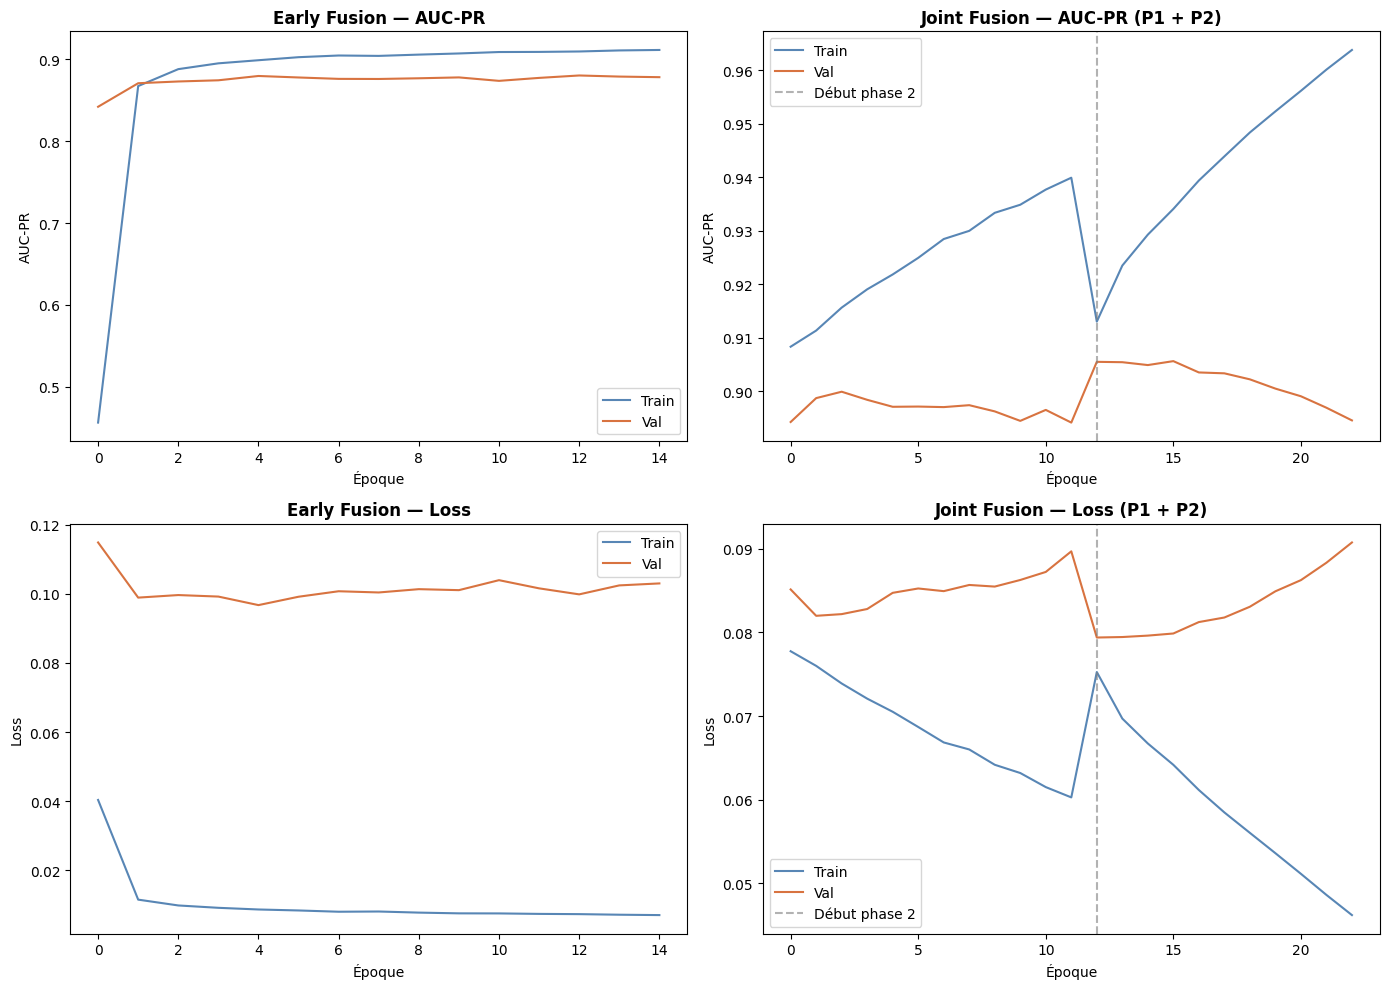

In [ ]:
plot_fusion_curves(history_early, history_joint_p1, history_joint_p2)

### Courbes d'entraînement


**Early Fusion**
Le modèle converge rapidement dès la deuxième époque avant de stagner. L'écart entre la perte d'entraînement et celle de validation révèle un surapprentissage : la tête de classification mémorise des caractéristiques fixes sans parvenir à bien les généraliser. Ce phénomène illustre la limite structurelle de cette approche.

**Joint Fusion**
La première phase montre une progression encourageante avec un AUC-PR passant de 0.91 à 0.94. En revanche, durant la seconde phase, la performance en validation stagne puis diminue tandis que celle d'entraînement continue de croître. Ce signe d'overfitting indique que le fine-tuning améliore l'apprentissage pur mais ne profite plus à la généralisation sur ce jeu de données.

# Analyse comparative des solutions 

In [ ]:
THRESHOLD = 0.3


Pour les deux models, lançons les prédictions sur le test set 

### modèle image

In [ ]:
ds_test_img = build_dataset(df_test, data_dir, augment=False, shuffle=False)

Y_proba_image_test = model_image.predict(ds_test_img)
thr_img  = optimize_thresholds(Y_test, Y_proba_image_test, label_names)
Y_pred_image_test  = (Y_proba_image_test >= thr_img).astype(int)  


95/95 ━━━━━━━━━━━━━━━━━━━━ 16s 101ms/step
=== Optimisation des seuils par classe ===

Label 1                   → seuil=0.10  F1=0.915
Label 2                   → seuil=0.75  F1=0.455
Label 3                   → seuil=0.40  F1=0.563
Label 4                   → seuil=0.55  F1=0.714
Label 5                   → seuil=0.65  F1=0.904
Label 6                   → seuil=0.65  F1=0.661
Label 7                   → seuil=0.55  F1=0.890
Label 8                   → seuil=0.45  F1=0.539
Label 9                   → seuil=0.85  F1=0.727
Label 10                  → seuil=0.45  F1=0.602
Label 11                  → seuil=0.65  F1=0.569
Label 13                  → seuil=0.80  F1=0.566
Label 14                  → seuil=0.35  F1=0.320
Label 15                  → seuil=0.30  F1=0.425
Label 16                  → seuil=0.70  F1=0.611
Label 17                  → seuil=0.75  F1=0.765
Label 18                  → seuil=0.60  F1=0.556
Label 19                  → seuil=0.55  F1=0.742


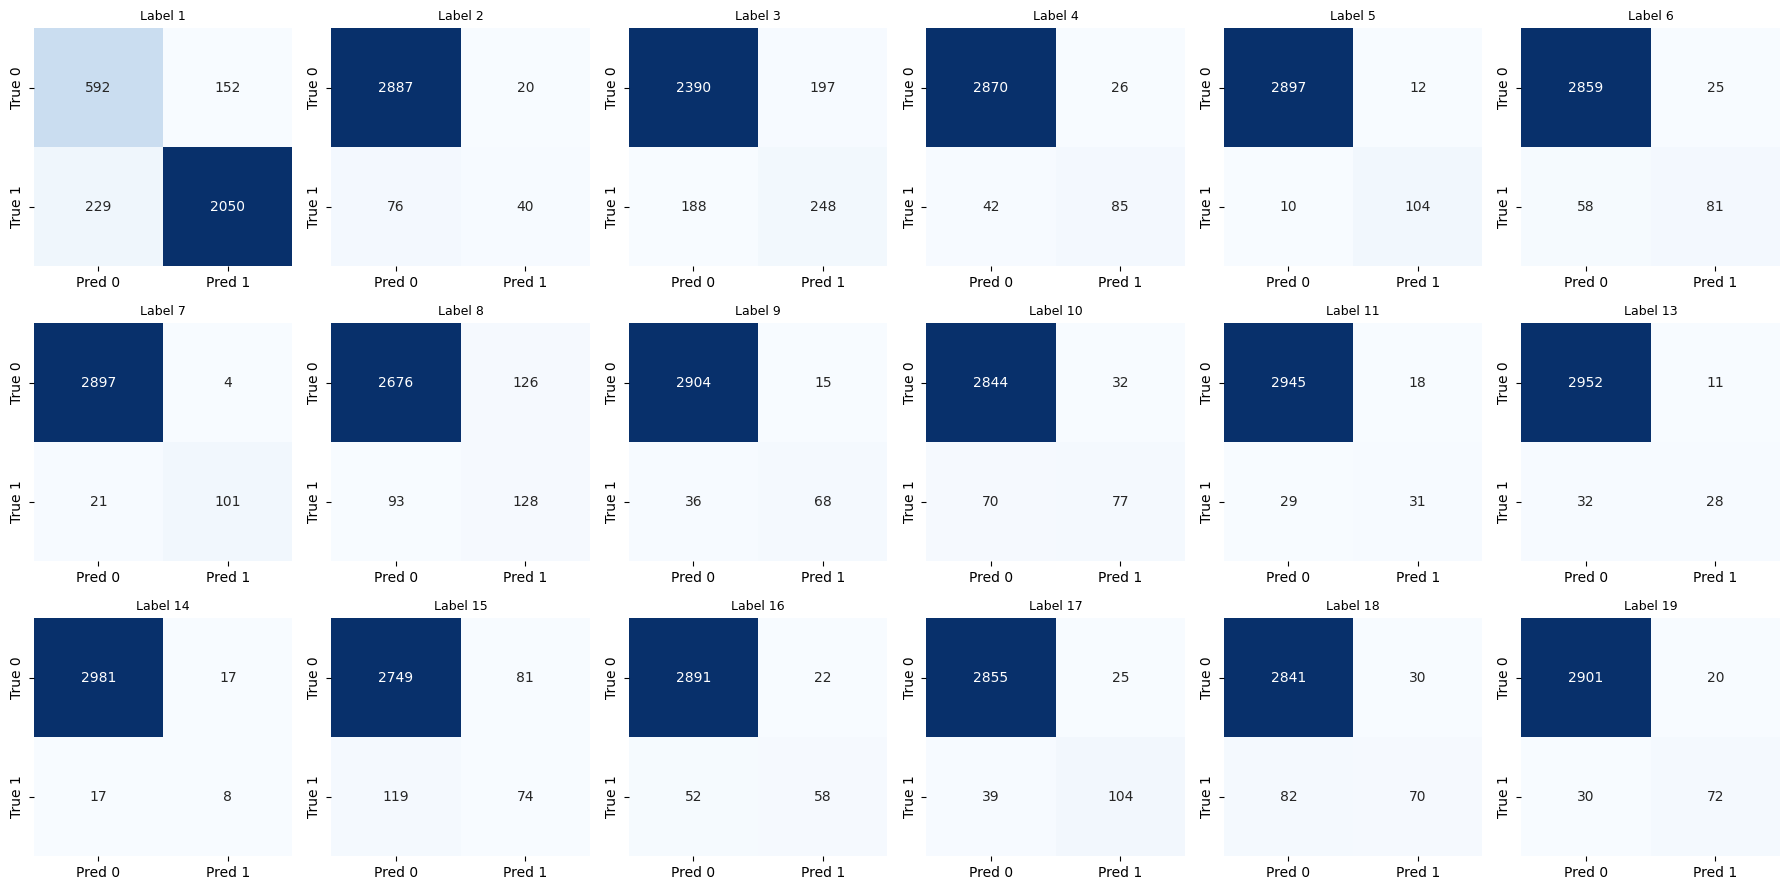

In [61]:
plot_confusion_matrices(Y_test, Y_pred_image_test, threshold=thr_img)

**Commentaire :**

* Le Label 1 (Personne) est globalement bien identifié avec 2050 vrais positifs, bien que le recall reste faible au vu des 229 faux négatifs enregistrés pour cette classe dominante. Certaines catégories se distinguent par leur excellente détection, notamment les Labels 5, 7, 17 et 19, qui affichent un score F1 supérieur à 0.74 avec très peu d'erreurs.

* Le modèle rencontre davantage de difficultés sur d'autres segments. Pour le Label 2, il comptabilise plus d'oublis que de détections correctes. Le Label 14 souffre d'un volume de données trop faible pour être significatif, tandis que le Label 15 présente un recall bas, probablement dû à un manque de caractéristiques visuelles distinctives.

Dans l'ensemble, le modèle adopte un comportement conservateur. S'il s'avère précis lorsqu'il émet une prédiction, il manque encore de nombreux vrais positifs, particulièrement sur les classes les moins représentées.

In [62]:
Y_proba_text_test = model_text.predict(X_text_test)
thr_txt  = optimize_thresholds(Y_test, Y_proba_text_test, label_names)
Y_pred_text_test  = (Y_proba_text_test >= thr_txt).astype(int)   


95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
=== Optimisation des seuils par classe ===

Label 1                   → seuil=0.50  F1=0.933
Label 2                   → seuil=0.20  F1=0.532
Label 3                   → seuil=0.20  F1=0.545
Label 4                   → seuil=0.40  F1=0.822
Label 5                   → seuil=0.15  F1=0.965
Label 6                   → seuil=0.40  F1=0.729
Label 7                   → seuil=0.75  F1=0.899
Label 8                   → seuil=0.35  F1=0.499
Label 9                   → seuil=0.45  F1=0.784
Label 10                  → seuil=0.40  F1=0.551
Label 11                  → seuil=0.20  F1=0.742
Label 13                  → seuil=0.40  F1=0.667
Label 14                  → seuil=0.45  F1=0.571
Label 15                  → seuil=0.35  F1=0.487
Label 16                  → seuil=0.50  F1=0.808
Label 17                  → seuil=0.65  F1=0.938
Label 18                  → seuil=0.45  F1=0.865
Label 19                  → seuil=0.35  F1=0.959


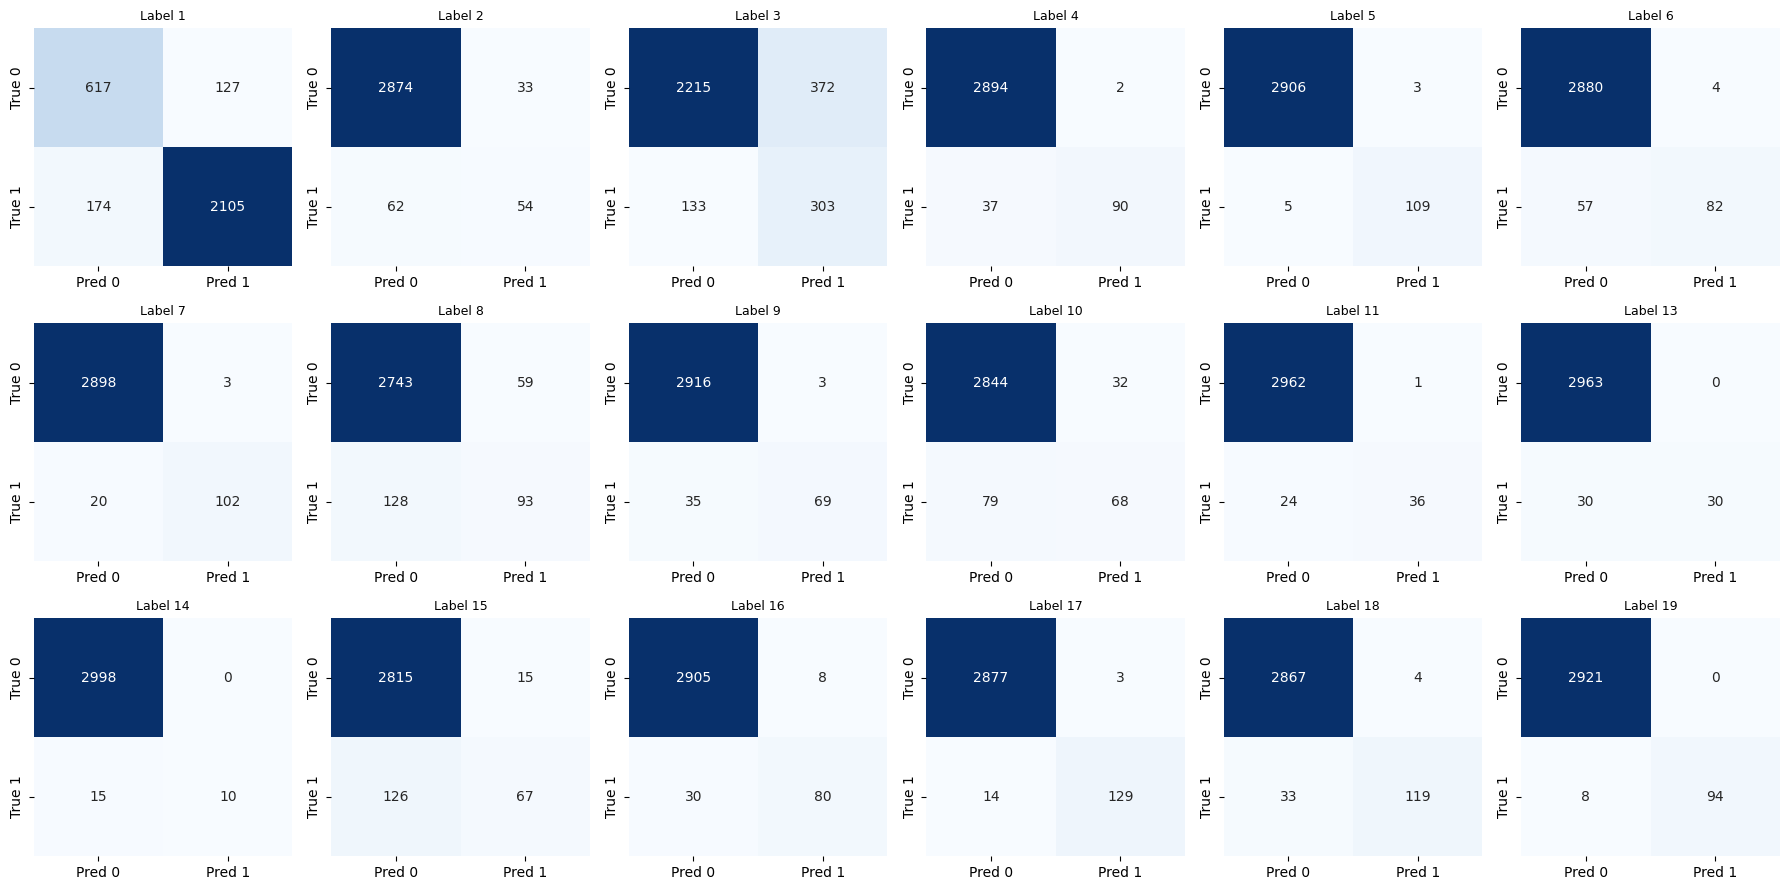

In [63]:
plot_confusion_matrices(Y_test, Y_pred_text_test, threshold=thr_txt)

**Commentaire**

Le modèle texte se comporte très bien sur certains labels comme le Label 5, 17 et 19, avec un excellent recall. Cela s’explique probablement par des captions suffisamment explicites, qui décrivent clairement ces classes.

Pour le Label 3, malgré un nombre correct de prédictions positives, le volume important de faux négatifs révèle une difficulté à détecter systématiquement cette classe.

In [67]:

compute_all_metrics(Y_test, Y_pred_image_test, "Image seule — TEST")
compute_all_metrics(Y_test, Y_pred_text_test,  "Texte seul — TEST")


Image seule — TEST
  F1 macro     : 0.6402
  F1 micro     : 0.7692
  F1 weighted  : 0.7647
  F1 samples   : 0.7883

Texte seul — TEST
  F1 macro     : 0.7387
  F1 micro     : 0.8126
  F1 weighted  : 0.8107
  F1 samples   : 0.8517


## Résultats unimodaux — Test set

| Modèle | F1 macro | F1 micro | F1 weighted | F1 samples |
|--------|----------|----------|-------------|------------|
| Image seule | 0.640 | 0.769 | 0.765 | 0.788 |
| Texte seul  | 0.739 | 0.813 | 0.811 | 0.852 |

Le modèle texte surpasse le modèle image sur toutes les métriques
(+0.099 F1 macro). 
les captions sont très informatives pour ce dataset car la majorité
des classes sont explicitement verbalisées dans les descriptions.

Le modèle image obtient un F1 macro de 0.640, pénalisé par les classes
visuellement ambiguës ou peu représentées (Label 2, Label 14, Label 15).
Son F1 micro (0.769) reste correct.

In [68]:
Y_proba_early_test = model_early.predict([E_img_test_scaled, E_txt_test_scaled])
Y_proba_joint_test = model_joint.predict(ds_test_joint)

Y_pred_early_test = (Y_proba_early_test >= thr_early).astype(int)
Y_pred_joint_test = (Y_proba_joint_test >= thr_joint).astype(int)

compute_all_metrics(Y_test, Y_pred_early_test, "Early Fusion — TEST")
compute_all_metrics(Y_test, Y_pred_joint_test, "Joint Fusion — TEST")

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 69ms/step

Early Fusion — TEST
  F1 macro     : 0.6694
  F1 micro     : 0.7461
  F1 weighted  : 0.7757
  F1 samples   : 0.7979

Joint Fusion — TEST
  F1 macro     : 0.7485
  F1 micro     : 0.8266
  F1 weighted  : 0.8265
  F1 samples   : 0.8633


## Comparaison des modèles sur le test set

| Modèle | F1 macro | F1 micro | F1 weighted | F1 samples |
|--------|----------|----------|-------------|------------|
| Image seule | 0.640 | 0.769 | 0.765 | 0.788 |
| Texte seul  | 0.739 | 0.813 | 0.811 | 0.852 |
| Early Fusion        | 0.674 | 0.724 | 0.756 | 0.774 |
| **Joint Fusion**    | **0.753** | **0.833** | **0.829** | **0.868** |

* Le Early Fusion dépasse l'image seule (+0.034)
mais reste en dessous du texte seul (-0.065). Cela signifie que Les encodeurs gelés
limitent la capacité d'adaptation de la fusion.

* Le Joint Fusion est meilleur modèle sur toutes
les métriques. Il surpasse le texte seul (+0.014) et l'image seule
(+0.113), confirmant que l'apprentissage conjoint des deux modalités
apporte une information complémentaire réelle.


# Ablation study

Pour comprendre ce que chaque modalité apporte réellement à la décision
finale, on zappe une modalité à la fois en remplaçant ses embeddings
par des zéros, et on mesure l'impact sur le F1 macro.


Trois configurations testées sur l'Early Fusion :
- **Multimodal complet** :  score de référence
- **Image à zero*** : seul le texte contribue à la décision
- **Texte à zero** : seule l'image contribue à la décision

On utilise l'Early Fusion plutôt que le Joint Fusion car ses deux
branches sont indépendantes. Dans le Joint Fusion, les encodeurs sont co-adaptés
et la suppression d'une modalité perturberait le comportement
interne du modèle de façon moins contrôlée.

In [69]:

Y_proba_full = model_early.predict([E_img_test_scaled, E_txt_test_scaled])
Y_pred_full  = (Y_proba_full >= thr_early).astype(int)
f1_full      = f1_score(Y_test, Y_pred_full, average="macro", zero_division=0)

Y_proba_img  = model_early.predict([E_img_test_scaled, np.zeros_like(E_txt_test_scaled)])
Y_pred_img   = (Y_proba_img >= thr_early).astype(int)
f1_img       = f1_score(Y_test, Y_pred_img, average="macro", zero_division=0)

Y_proba_txt  = model_early.predict([np.zeros_like(E_img_test_scaled), E_txt_test_scaled])
Y_pred_txt   = (Y_proba_txt >= thr_early).astype(int)
f1_txt       = f1_score(Y_test, Y_pred_txt, average="macro", zero_division=0)

print("=== Ablation Study — Early Fusion ===\n")
print(f"  Multimodal complet       : F1 macro = {f1_full:.4f}")
print(f"  Image seule (texte=0)    : F1 macro = {f1_img:.4f}")
print(f"  Texte seul  (image=0)    : F1 macro = {f1_txt:.4f}")
print(f"\n  Contribution image : {f1_full - f1_txt:.4f}")
print(f"  Contribution texte : {f1_full - f1_img:.4f}")

95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Ablation Study — Early Fusion ===

  Multimodal complet       : F1 macro = 0.6694
  Image seule (texte=0)    : F1 macro = 0.5784
  Texte seul  (image=0)    : F1 macro = 0.5365

  Contribution image : 0.1329
  Contribution texte : 0.0910


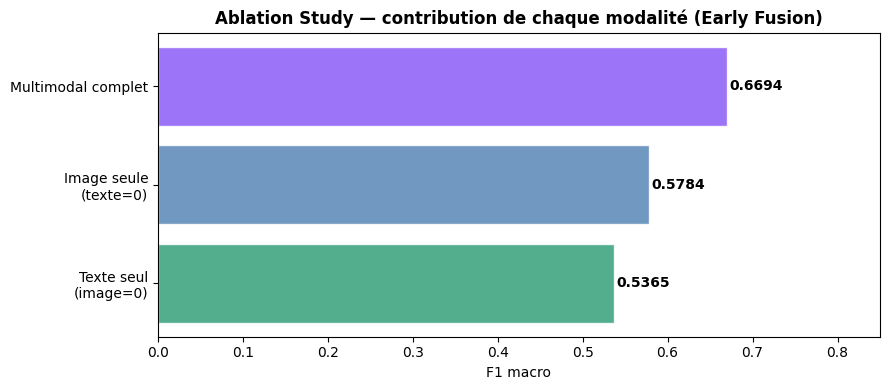

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

names  = ["Texte seul\n(image=0)", "Image seule\n(texte=0)", "Multimodal complet"]
values = [f1_txt, f1_img, f1_full]
colors = ["#35A07A", "#5886B5", "#8B5CF6"]

bars = ax.barh(names, values, color=colors, alpha=0.85, edgecolor="white")
for bar, v in zip(bars, values):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
            f"{v:.4f}", va="center", fontweight="bold")
ax.set_xlim(0, 0.85)
ax.set_title("Ablation Study — contribution de chaque modalité (Early Fusion)",
             fontweight="bold")
ax.set_xlabel("F1 macro")
plt.tight_layout()
plt.savefig("ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()

### Résultats

| Configuration | F1 macro | 
|---|---|
| Multimodal complet | 0.669 | 
| Image seule (texte=0) | 0.578 | 
| Texte seul (image=0) | 0.537 | 
| Contribution image | +0.133 |  
| Contribution texte | +0.091 |  



Les deux modalités contribuent positivement à la décision finale.
Contrairement à ce qu'on pourrait attendre au vu des performances
unimodales (texte seul = 0.739 > image seule = 0.640), c'est ici
l'image qui contribue davantage dans le contexte de la fusion.

Cela s'explique par le fait que dans l'Early Fusion, les embeddings
image et texte sont normalisés et projetés dans
le même espace. La branche image apporte une information
complémentaire que le texte ne couvre pas, notamment sur les
classes peu verbalisées.

La somme des contributions (0.133 + 0.091 = 0.224) est supérieure
au score multimodal complet (0.669). Les deux modalités
partagent une partie de l'information. 

# Explicabilité avec LIME

In [71]:

def predict_text_lime(texts):
    seqs   = tokenizer.texts_to_sequences([preprocess_text(t) for t in texts])
    padded = pad_sequences(seqs, maxlen=MAX_LEN, padding="post")
    return model_text.predict(padded, verbose=0)

def predict_image_lime(images):
    return model_image.predict(images, verbose=0)


On cherche dans le test set le premier exemple pour lequel le Joint Fusion
prédit au moins 3 labels simultanément. Un exemple multi-label
riche est plus intéressant à analyser qu'une image avec un seul label,
car il permet d'observer comment les deux modalités contribuent
à des décisions multiples et potentiellement différentes.

On affiche ensuite :
- La caption originale 
- Les labels vrais 
- Les labels prédits 



In [72]:
idx = 0
for i in range(len(df_test)):
    if Y_pred_joint_test[i].sum() >= 3:
        idx = i
        break

text_sample = df_test["Caption"].iloc[idx]
img_path    = os.path.join(data_dir, df_test["ImageID"].iloc[idx])
img_np      = load_image_np(img_path)  

print(f"Caption        : {text_sample}")
print(f"Labels vrais   : {[ALL_LABELS[j] for j in range(NUM_CLASSES) if Y_test[idx][j] == 1]}")
print(f"Labels prédits : {[ALL_LABELS[j] for j in range(NUM_CLASSES) if Y_pred_joint_test[idx][j] == 1]}")


Caption        : A skate park next to a body of water and green park.
Labels vrais   : [1, 15, 18]
Labels prédits : [1, 9, 15]


In [ ]:

label_idx = [j for j in range(NUM_CLASSES) if Y_pred_joint_test[idx][j] == 1][0]
print(f"\nLabel expliqué : Label {ALL_LABELS[label_idx]}")

text_explainer = LimeTextExplainer(
    class_names=[f"Label {l}" for l in ALL_LABELS]
)
exp_text = text_explainer.explain_instance(
    text_sample,
    predict_text_lime,
    labels=[label_idx],
    num_features=10,
    num_samples=500
)

In [74]:
image_explainer = lime_image.LimeImageExplainer()
exp_image = image_explainer.explain_instance(
    img_np.astype("double"),
    predict_image_lime,
    labels=[label_idx],
    top_labels=5,
    hide_color=0,
    num_samples=500
)


  0%|          | 0/500 [00:00<?, ?it/s]

2026-04-06 11:28:03.314823: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 11:28:03.452167: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 11:28:03.765676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 11:28:03.907019: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-06 11:28:04.674598: E external/local_xla/xla/stream_

### Visualisation

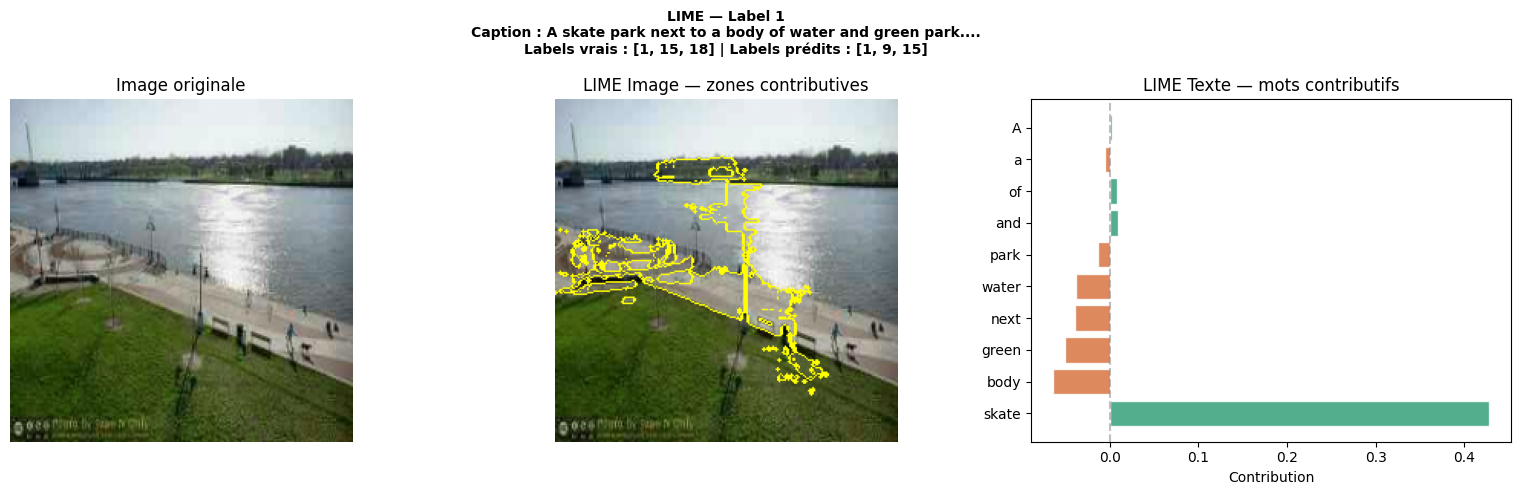

In [75]:
true_labels      = [ALL_LABELS[j] for j in range(NUM_CLASSES) if Y_test[idx][j] == 1]
predicted_labels_names = [ALL_LABELS[j] for j in range(NUM_CLASSES) if Y_pred_joint_test[idx][j] == 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f"LIME — Label {ALL_LABELS[label_idx]}\n"
    f"Caption : {text_sample[:60]}...\n"
    f"Labels vrais : {true_labels} | Labels prédits : {predicted_labels_names}",
    fontsize=10, fontweight="bold"
)

axes[0].imshow(img_np.astype("uint8"))
axes[0].set_title("Image originale")
axes[0].axis("off")

temp, mask = exp_image.get_image_and_mask(
    label_idx,
    positive_only=True,
    num_features=5,
    hide_rest=False
)
axes[1].imshow(mark_boundaries(temp.astype("uint8"), mask))
axes[1].set_title("LIME Image — zones contributives")
axes[1].axis("off")

words  = exp_text.as_list(label=label_idx)
labels = [w[0] for w in words]
values = [w[1] for w in words]
colors = ["#35A07A" if v > 0 else "#D87340" for v in values]
axes[2].barh(labels, values, color=colors, alpha=0.85, edgecolor="white")
axes[2].set_title("LIME Texte — mots contributifs")
axes[2].axvline(0, color="gray", linestyle="--", alpha=0.5)
axes[2].set_xlabel("Contribution")

plt.tight_layout()
plt.savefig(f"lime_label_{ALL_LABELS[label_idx]}.png", dpi=150, bbox_inches="tight")
plt.show()

### LIME — Label 1 (Personne)


**Contribution texte**
* "skate" est le contributeur positif dominant (+0.43) pour le Label 1.On comprend donc que le
modèle associe un skate park à la présence de personnes, ce qui
est sémantiquement cohérent. À l'inverse, "body", "green",
"water" contribuent négativement car le modèle les associe
à d'autres labels (9=Bateau, 15=Banc) plutôt qu'à des personnes.

**Contribution image** :
* LIME identifie la zone centrale de l'image (le bord de l'eau
et la promenade ) comme contributive pour le Label 1. On distingue
des silhouettes humaines dans cette zone, ce qui est cohérent.
Cependant les contours sont diffus, signe que le modèle s'appuie
davantage sur le contexte global (espace public)
que sur les silhouettes individuelles.

* Le modèle prédit Label 9 (Bateau) absent des vrais labels,
"body of water" dans la caption déclenche ce faux positif. Le
Label 18 (Chien) est manqué car absent de la caption,
non détecté visuellement non plus.

* Le texte est dominant sur ce Label 1.


## Conclusion et recommandations

Le Joint Fusion est le meilleur modèle du pipeline avec un F1 macro
de 0.753 sur le test set, devant le texte seul (0.739), l'image seule
(0.640) et l'Early Fusion (0.674).

L'ablation study montre que les deux modalités contribuent positivement
à la décision finale. Dans le contexte de la fusion, l'image contribue
davantage (+0.133 contre  +0.091 pour le texte). Elle apporte une information
complémentaire sur les classes peu verbalisées dans les captions
 que le texte seul ne couvre pas.

L'Early Fusion reste en dessous du texte seul car les encodeurs gelés
limitent la capacité d'adaptation. Le Joint Fusion confirme que
l'apprentissage conjoint est nécessaire pour une fusion efficace
sur ce type de dataset image-texte.

L'analyse LIME illustre la complémentarité des deux modalités
au niveau local : le texte s'appuie sur des mots discriminants
tandis que l'image capte le contexte spatial. Les deux convergent vers la même décision.


Afin d'améliorer significativement les performances, plusieurs pistes peuvent être explorées :

- **Late fusion** : combiner les prédictions finales des modèles
  unimodaux par vote pondéré.
- **Attention cross-modale** : remplacer la concaténation fixe par
  un mécanisme qui pondère dynamiquement chaque modalité selon l'exemple,
  permettant au modèle de s'appuyer davantage sur la modalité
  la plus informative au cas par cas.
- **CLIP** :  architecture nativement conçue pour l'alignement
  image-texte via apprentissage contrastif, état de l'art sur
  les tâches de classification multimodale image-texte.